In [ ]:
import DataLoaderPipeline as dplmodule
from DataLoaderPipeline import DataLoaderPipeline
import importlib
importlib.reload(dplmodule)
DATA_PATH = "data/CASIA_FASD_V3_224x224/DATA"
DATA_MAP_PATH = "data_maps/CASIA_FASD_V3_30percent_uniformSampling.json"

all_subjects = [f"{i:02d}" for i in range(1, 51)]  # Generate subject IDs from '01' to '50'.
train_subs = all_subjects[:20]
val_subs = all_subjects[20:25] 
test_subs = all_subjects[20:] 
config={
        "filtering_params": {
            "data_map_path": "data_maps/CASIA_FASD_v3_all.json",
        },

        "data_params": {
            "dataset_path": "data/CASIA_FASD_v3_224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32,
            "validation_subjects_number": 0, # < 5 # Number of subjects to be used for validation (the will not be used for training)
            "get_random_subjects_for_validation": 0, # 1 for random selection, 0 for fixed selection (the first N subjects in the dataset)
            "validation_dataset_baleance": 0, # 0 for unbalanced, 1 for balanced
        },        
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 0,
            "brightness_delta": 0.1, # -1.0 to 1.0, 0 for no change
            "contrast_range": [0.9, 1.1], # [lower, upper], 1.0 for no change
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": None,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 5,
            "learning_rate": 0.0001,
            "initial_epochs": 1
        }      
    }

dlp = DataLoaderPipeline(data_params=config["data_params"],
                         filtering_params=config["filtering_params"],
                         augmentation_params=config["augmentation_params"])


train_ds = dlp.build_pipeline(train_subs, balanced=True, augment=True)
val_ds   = dlp.build_pipeline(val_subs, balanced=False, augment=False)
test_ds  = dlp.build_pipeline(test_subs, balanced=False, augment=False)
# for ds in [train_ds, val_ds, test_ds]:
#     dlp.audit_dataset(ds, batchs=20)

Successfully loaded 50 subjects from JSON.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_multi_colorspace_model(input_shape=(224, 224, 3)):
    # 1. Input Layer (RGB)
    input_rgb = layers.Input(shape=input_shape, name="input_rgb")
    
    # 2. Color Space Transformations
    # Note: TF expects images in [0, 1] for these built-in functions
    input_hsv = layers.Lambda(lambda x: tf.image.rgb_to_hsv(x), name="rgb_to_hsv")(input_rgb)
    input_ycbcr = layers.Lambda(lambda x: tf.image.rgb_to_yuv(x), name="rgb_to_ycbcr")(input_rgb)
    
    # 3. Concatenate all 9 channels (3 RGB + 3 HSV + 3 YCbCr)
    # Shape transition: (Batch, 224, 224, 3) -> (Batch, 224, 224, 9)
    merged_channels = layers.Concatenate(axis=-1, name="nine_channel_fusion")(
        [input_rgb, input_hsv]
    )
    
    # 4. Feature Extraction (Example: Lightweight CNN for Spoofing)
    # Since you have 9 channels, the first Conv layer will learn cross-color correlations
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(merged_channels)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    # 5. Output Layer (Binary Classification: Real vs Spoof)
    output = layers.Dense(1, activation='sigmoid', name="classifier")(x)
    
    model = models.Model(inputs=input_rgb, outputs=output, name="MultiColorspace_Spoofing_Detector")
    return model

# Instantiate for your TrainingPipeline
model = build_multi_colorspace_model()
model.summary()

In [ ]:

def build_mc_cdcn_model(input_shape=(224, 224, 3), theta=0.7):
    """
    Builds the MC-CDCN model for Intelligent Facial Spoofing Detection.
    Combines RGB, HSV, YCrCb with Central Difference Convolutions.
    """
    
    # --- Custom CDC Layer inside the function for portability ---
    class CDC2D(layers.Layer):
        def __init__(self, filters, kernel_size=3, theta=0.7, **kwargs):
            super().__init__(**kwargs)
            self.filters, self.kernel_size, self.theta = filters, kernel_size, theta
            self.conv = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)
        def call(self, x):
            out_normal = self.conv(x)
            kernel_sum = tf.reduce_sum(self.conv.kernel, axis=(0, 1))
            out_center = tf.nn.convolution(x, tf.reshape(kernel_sum, (1, 1, x.shape[-1], self.filters)), padding='SAME')
            return out_normal - self.theta * out_center
        def get_config(self):
            return {**super().get_config(), "filters": self.filters, "kernel_size": self.kernel_size, "theta": self.theta}

    # --- 1. Inputs & Multi-Chromatic Fusion ---
    input_rgb = layers.Input(shape=input_shape, name="input_rgb")
    
    # Normalize and transform color spaces
    # Note: Assumes input is [0, 255], scales to [0, 1] for transformations
    x_norm = layers.Rescaling(1./255)(input_rgb)
    input_hsv = layers.Lambda(lambda x: tf.image.rgb_to_hsv(x), name="hsv_transform")(x_norm)
    input_ycbcr = layers.Lambda(lambda x: tf.image.rgb_to_yuv(x), name="ycbcr_transform")(x_norm)
    
    merged = layers.Concatenate(axis=-1, name="9_channel_fusion")([x_norm, input_hsv, input_ycbcr])

    # --- 2. Feature Extraction Blocks (CDC + Residual) ---
    def cdc_res_block(x, filters, stride=1):
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(x)
        
        # Branch with Central Difference
        val = CDC2D(filters, theta=theta)(x)
        val = layers.BatchNormalization()(val)
        val = layers.Activation('relu')(val)
        if stride > 1: val = layers.MaxPooling2D((stride, stride))(val)
        
        val = layers.Conv2D(filters, (3, 3), padding='same')(val)
        val = layers.BatchNormalization()(val)
        
        return layers.Add()([shortcut, val])

    # Block 1: Initial texture extraction
    x = cdc_res_block(merged, 64)
    x = layers.MaxPooling2D((2, 2))(x) # 112x112

    # Block 2: Middle-level features with Spatial Attention
    x = cdc_res_block(x, 128)
    attn = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    x = layers.Multiply()([x, attn])
    x = layers.MaxPooling2D((2, 2))(x) # 56x56

    # Block 3: High-level semantics
    x = cdc_res_block(x, 256)

    # --- 3. Global Head ---
    # Combine Average and Max pooling to catch both global structure and local "glints"
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    combined = layers.Concatenate()([gap, gmp])
    
    x = layers.Dense(128, activation='relu', kernel_regularizer='l2')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid', name="classifier")(x)

    return models.Model(inputs=input_rgb, outputs=output, name="MC_CDCN")
build_mc_cdcn_model().summary()

In [442]:
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers

def visualize(original, augmented, cmap='gray'):
  fig = plt.figure(figsize=(6, 3))
  plt.subplot(1,2,1)
  plt.imshow(original, cmap= cmap)

  plt.subplot(1,2,2)
  plt.imshow(augmented, cmap= cmap)
  plt.show()


from skimage.feature import local_binary_pattern

# Settings for LBP
radius = 1
n_points = 8 * radius

def get_lbp_map(image):
    # image should be grayscale or a single channel like Saturation
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')
    return lbp

In [458]:
import numpy as np
train_subs = [f"{i:02d}" for i in range(1, 21)]  # Generate subject IDs from '01' to '20'.
sub = np.random.choice(train_subs)

real_img = cv2.imread(f"./data/CASIA_FASD_V3/DATA/{sub}/real/{sub}_01_001.jpg", cv2.IMREAD_COLOR_RGB)
spoof_img = cv2.imread(f"./data/CASIA_FASD_V3/DATA/{sub}/spoof/{sub}_03_001.jpg", cv2.IMREAD_COLOR_RGB)

real_img=cv2.resize(real_img, (224,224))
spoof_img=cv2.resize(spoof_img, (224,224))

# plt.imshow(real_img)
real_img.shape

(224, 224, 3)

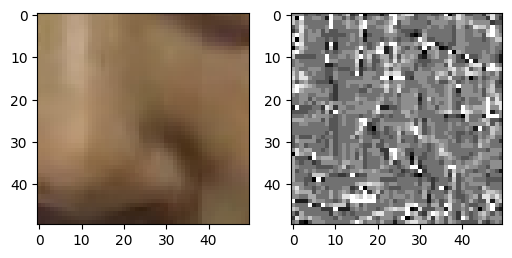

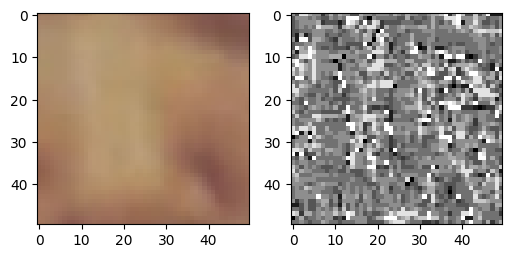

In [459]:
lbp = get_lbp_map(real_img[:,:,2])  # Using the Saturation channel for LBP
visualize(real_img[100:150,100:150], lbp[100:150,100:150])

lbp = get_lbp_map(spoof_img[:,:,2])  # Using the Saturation channel for LBP
visualize(spoof_img[100:150,100:150], lbp[100:150,100:150])

In [189]:
sub

np.str_('11')

In [124]:
real_img = tf.image.adjust_saturation(real_img, 2).numpy()
spoof_img = tf.image.adjust_saturation(spoof_img, 2).numpy()

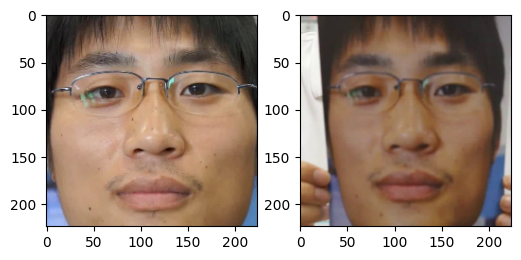

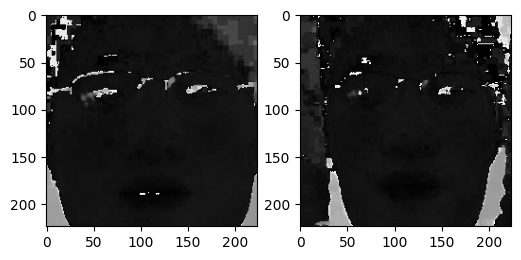

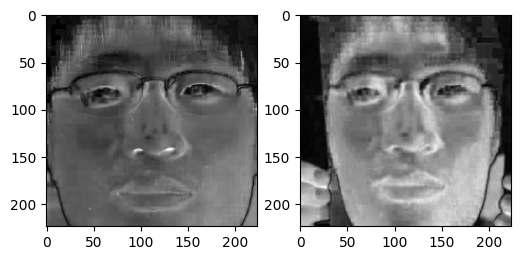

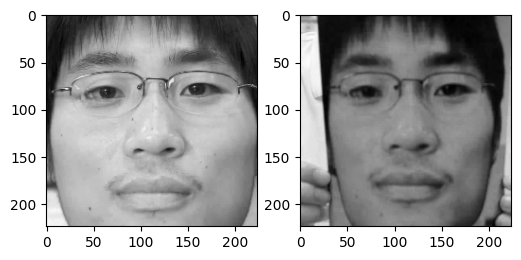

In [418]:

visualize(real_img, spoof_img)
mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,0]  
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 0]  
visualize(mod_real_img, mod_spoof_img ,cmap='gray')

mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,1] 
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 1]  
visualize(mod_real_img, mod_spoof_img ,cmap='gray')

mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,2]
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 2]  
visualize(mod_real_img, mod_spoof_img ,cmap='gray')

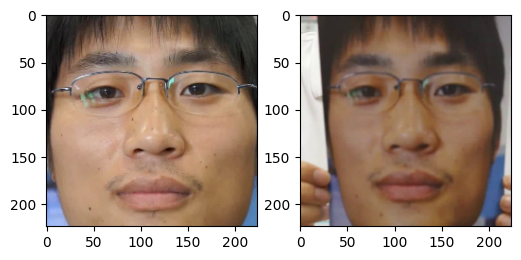

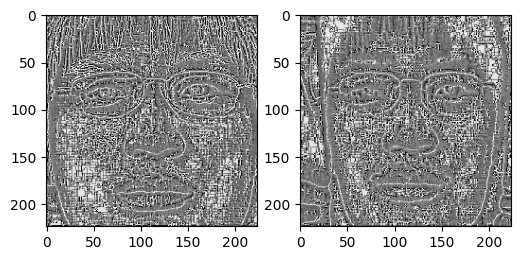

In [424]:
visualize(real_img, spoof_img)
mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,0]  
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 0]  
# visualize(get_lbp_map(mod_real_img.numpy()), get_lbp_map(mod_spoof_img.numpy()), cmap='gray')

mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,1] 
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 1]  
# visualize(get_lbp_map(mod_real_img.numpy()), get_lbp_map(mod_spoof_img.numpy()), cmap='gray')

mod_real_img = tf.image.rgb_to_hsv(real_img)[:,:,2]
mod_spoof_img = tf.image.rgb_to_hsv(spoof_img)[:, :, 2]  
visualize(get_lbp_map(mod_real_img.numpy()), get_lbp_map(mod_spoof_img.numpy()), cmap='gray')

In [ ]:
import tensorflow as tf
import numpy as np

def get_lbp_gpu(image_channel, keep_border=True):
    """
    Compute exact skimage LBP (P=8, R=1, method='default') with conv2d.

    Why diagonals are not simple corner pixels:
    skimage samples points on a circle of radius 1. For diagonal directions,
    sample locations are fractional (+/-0.707, +/-0.707), so bilinear interpolation
    is used. These kernels encode (interpolated_neighbor - center) exactly.

    Args:
        image_channel: Tensor shape [B, H, W, 1].
        keep_border: SAME padding if True, VALID if False.
    """
    x = tf.convert_to_tensor(image_channel, dtype=tf.float32)

    a = np.float32(0.20710678)  # 0.70710678 * 0.29289322
    b = np.float32(0.5)         # 0.70710678 * 0.70710678
    c = np.float32(0.91421354)  # 1 - 0.08578644

    # Neighbor order follows skimage p=0..7:
    # Right, Top-Right, Top, Top-Left, Left, Bottom-Left, Bottom, Bottom-Right
    kernels = np.array([
        [[0, 0, 0], [0, -1, 1], [0, 0, 0]],
        [[0, a, b], [0, -c, a], [0, 0, 0]],
        [[0, 1, 0], [0, -1, 0], [0, 0, 0]],
        [[b, a, 0], [a, -c, 0], [0, 0, 0]],
        [[0, 0, 0], [1, -1, 0], [0, 0, 0]],
        [[0, 0, 0], [a, -c, 0], [b, a, 0]],
        [[0, 0, 0], [0, -1, 0], [0, 1, 0]],
        [[0, 0, 0], [0, -c, a], [0, a, b]],
    ], dtype=np.float32).transpose(1, 2, 0).reshape(3, 3, 1, 8)

    weights = tf.reshape(tf.constant([1, 2, 4, 8, 16, 32, 64, 128], dtype=tf.float32), (1, 1, 1, 8))

    padding_mode = 'SAME' if keep_border else 'VALID'
    diff = tf.nn.conv2d(x, tf.constant(kernels), strides=[1, 1, 1, 1], padding=padding_mode)

    binary_bits = tf.cast(diff >= 0.0, tf.float32)
    lbp_map = tf.reduce_sum(binary_bits * weights, axis=-1, keepdims=True)
    return lbp_map

In [674]:
def get_lbp_gpu(image_channel , keep_border=True):
    # Define constants as Tensors immediately
    a = tf.constant(0.20710678, dtype=tf.float32) 
    b = tf.constant(0.5, dtype=tf.float32)        
    c = tf.constant(0.91421354, dtype=tf.float32) 

    # Create the kernels using tf.stack instead of np.array
    # This keeps everything inside the TF ecosystem
    k0 = [[0, 0, 0], [0, -1, 1], [0, 0, 0]]
    k1 = [[0, a, b], [0, -c, a], [0, 0, 0]]
    k2 = [[0, 1, 0], [0, -1, 0], [0, 0, 0]]
    k3 = [[b, a, 0], [a, -c, 0], [0, 0, 0]]
    k4 = [[0, 0, 0], [1, -1, 0], [0, 0, 0]]
    k5 = [[0, 0, 0], [a, -c, 0], [b, a, 0]]
    k6 = [[0, 0, 0], [0, -1, 0], [0, 1, 0]]
    k7 = [[0, 0, 0], [0, -c, a], [0, a, b]]

    # Stack and reshape to [height, width, in_channels, out_channels]
    kernels = tf.stack([k0, k1, k2, k3, k4, k5, k6, k7], axis=0)
    kernels = tf.transpose(kernels, [1, 2, 0])
    kernels = tf.reshape(kernels, (3, 3, 1, 8))

    weights = tf.reshape(tf.constant([1, 2, 4, 8, 16, 32, 64, 128], dtype=tf.float32), (1, 1, 1, 8))

    # Standard Conv2D logic
    padding_mode = 'SAME' if keep_border else 'VALID'
    diff = tf.nn.conv2d(image_channel, kernels, strides=[1, 1, 1, 1], padding=padding_mode)
    binary_bits = tf.cast(diff >= -1e-7, tf.float32)
    
    return tf.reduce_sum(binary_bits * weights, axis=-1, keepdims=True)

In [709]:
import numpy as np
import tensorflow as tf
from skimage.feature import local_binary_pattern

# 1. Create a dummy "texture" image
img_np = np.random.rand(224, 224).astype(np.float32)  # Grayscale image with values in [0, 1]
# [B, H, W, C]
img_tf = tf.convert_to_tensor(img_np[np.newaxis, ..., np.newaxis], dtype=tf.float32)

# 2. Reference LBP (scikit-image)
lbp_skimage = local_binary_pattern(img_np, P=8, R=1, method='default')

# 3. Convolution LBP on VALID region only (no border effect)
lbp_tf_valid = get_lbp_gpu(img_tf, keep_border=False).numpy()[0, :, :, 0]

# Center-valid region of skimage is [1:-1, 1:-1]
lbp_ref_valid = lbp_skimage[1:-1, 1:-1]

print("Skimage valid region:\n", lbp_ref_valid)
print("\nTF conv valid region:\n", lbp_tf_valid)

mse = np.mean((lbp_ref_valid - lbp_tf_valid) ** 2)
print(f"\nEquality Check (MSE): {mse}")

lbp_tf_valid[0,0]

Skimage valid region:
 [[255.   0.  16. ... 254. 255.   1.]
 [  0. 255. 141. ... 248. 251. 231.]
 [239. 192. 255. ...   0. 145.  64.]
 ...
 [ 25. 129. 192. ...   1.   0.  28.]
 [ 78.  63.   1. ...  70.  63. 141.]
 [  0. 254. 255. ...   0. 126. 191.]]

TF conv valid region:
 [[255.   0.  16. ... 254. 255.   1.]
 [  0. 255. 141. ... 248. 251. 231.]
 [239. 192. 255. ...   0. 145.  64.]
 ...
 [ 25. 129. 192. ...   1.   0.  28.]
 [ 78.  63.   1. ...  70.  63. 141.]
 [  0. 254. 255. ...   0. 126. 191.]]

Equality Check (MSE): 0.0


np.float32(255.0)

In [741]:
import architectures
importlib.reload(architectures)
model = architectures.HS_LBP_ConvNeXt()

In [742]:
# 1. Create a dummy "texture" image
img_np = np.random.rand(224, 224, 3).astype(np.float32)  # RGB image with values in [0, 1]
# [B, H, W, C]
img_tf = tf.convert_to_tensor(img_np[np.newaxis, ..., :], dtype=tf.float32)

label = model(img_tf)
label

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.51222813]], dtype=float32)>

# configs

In [ ]:

configs_example = [
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_10percent_BMSelection.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 20,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_30percent_BMSelection.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 20,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_50percent_uniformSampling.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 20,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_all.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 20,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1500,
            "initial_epochs": 50
        }      
    },
]


In [ ]:

configs_example = [
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_10percent_BMSelection.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 10,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_30percent_BMSelection.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 10,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_30percent_uniformSampling.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 10,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_50percent_uniformSampling.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 10,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1000,
            "initial_epochs": 50
        }      
    },
    {
        "data_params": {
            "dataset_path": "/kaggle/input/datasets/maameri/visual-computing-thesis-data-224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32                
        },
        
        "filtering_params": {
            "data_map_path": "/kaggle/working/face-anti-spoofing-pipline/data_maps/CASIA_FASD_V3_all.json",
        },
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 1,
            "brightness_range": [0.9,1.1],
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": init_model,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 10,
            "learning_rate": 0.00005,
            "steps_per_epoch": 1500,
            "initial_epochs": 50
        }      
    },
]
